# About Dataset
* This dataset provides synthetic yet realistic data for analyzing and forecasting retail store inventory demand. It contains over 73000 rows of daily data across multiple stores and products, including attributes like sales, inventory levels, pricing, weather, promotions, and holidays.

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# reading the dataset
store_df = pd.read_csv('./retail_store_inventory.csv')
store_df.sample(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
54858,2023-07-03,S003,P0019,Clothing,North,308,86,81,78.34,96.69,5,Cloudy,1,101.49,Autumn
25458,2022-09-12,S003,P0019,Groceries,West,114,110,139,110.78,25.46,15,Sunny,1,25.47,Summer
58548,2023-08-09,S003,P0009,Electronics,North,325,65,162,67.42,50.46,5,Snowy,1,54.18,Winter
23179,2022-08-20,S004,P0020,Electronics,South,222,97,141,104.59,15.17,5,Rainy,0,14.56,Winter
3735,2022-02-07,S002,P0016,Groceries,North,298,96,139,95.00,44.03,0,Snowy,0,45.71,Winter
16110,2022-06-11,S001,P0011,Electronics,West,453,142,38,147.67,84.17,5,Cloudy,1,81.48,Spring
22977,2022-08-18,S004,P0018,Furniture,West,66,44,171,62.89,75.30,20,Snowy,1,70.46,Autumn
42691,2023-03-03,S005,P0012,Electronics,West,369,187,32,200.48,38.11,0,Sunny,0,42.71,Spring
34433,2022-12-11,S002,P0014,Clothing,East,495,47,95,60.51,20.33,15,Snowy,1,20.32,Spring
71052,2023-12-12,S003,P0013,Clothing,South,445,98,178,98.99,32.43,20,Snowy,1,28.25,Spring


In [46]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [47]:
round(store_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.0,274.47,129.95,50.00,162.00,273.00,387.00,500.00
Units Sold,73100.0,136.46,108.92,0.00,49.00,107.00,203.00,499.00
Units Ordered,73100.0,110.00,52.28,20.00,65.00,110.00,155.00,200.00
Demand Forecast,73100.0,141.49,109.25,-9.99,53.67,113.02,208.05,518.55
Price,73100.0,55.14,26.02,10.00,32.65,55.05,77.86,100.00
Discount,73100.0,10.01,7.08,0.00,5.00,10.00,15.00,20.00
Holiday/Promotion,73100.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Competitor Pricing,73100.0,55.15,26.19,5.03,32.68,55.01,77.82,104.94


In [48]:
# FINDIND UNIQUE VALUES FOR CATEGORICAL AND NUMERICAL COLUMNS
numerical_cols = store_df.select_dtypes(include = np.number).columns.tolist()

for cols in numerical_cols:
    unique_value = store_df[cols].unique()
    print(f"Column : {cols}")
    print(f"Unique : {unique_value}")

Column : Inventory Level
Unique : [231 204 102 469 166 138 359 380 183 108 258  66  96 193 379 363 318 241
 352 274 343 373 445 191 281 492 460 304 113 157  67 389 465 197 242 398
 234 221 115 375 153 438 456 189 223 381 292 311  51 487 429 330 431 477
 462 446 437 397 470 264 250  63 447 205 349 406 228 263 203 143 211 111
 415 384 436 180 185 478 182  87 427 245 317 325 411  71 388 161 235 116
 416 488 248 238 471 178  92  99 171 215 455  84 246 399 156 402 132 218
 131  93 344 340 296 472 308 434 287 190 353 210 124 222 277 175 120 302
 219 146 260 414 420 435 230 319  59 155 144 283 347 410  97 339 110 348
 458 403 198 254 100 442  76 257 119  60 289 418  89 421 154 282 239 368
  57 214 407 252  72 194 148 315 240 405 200 327 409 483  70 288 270 217
 303 298 365 271 134 290 448 186 413 112 268 495 324 297 169 188 149 383
  73 467 129 301 423 385  74 140 159 322 106 475  83 117 207 476  77 419
 184 361 376 451  85  91 209 127 367 404 494 150  94 430 168 109 493 425
 118 449 216 291 

In [49]:
categorical_cols = store_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols:
    unique_value = store_df[cols].unique()
    print(f"Column : {cols}")
    print(f"Unique : {unique_value}")

Column : Date
Unique : ['2022-01-01' '2022-01-02' '2022-01-03' '2022-01-04' '2022-01-05'
 '2022-01-06' '2022-01-07' '2022-01-08' '2022-01-09' '2022-01-10'
 '2022-01-11' '2022-01-12' '2022-01-13' '2022-01-14' '2022-01-15'
 '2022-01-16' '2022-01-17' '2022-01-18' '2022-01-19' '2022-01-20'
 '2022-01-21' '2022-01-22' '2022-01-23' '2022-01-24' '2022-01-25'
 '2022-01-26' '2022-01-27' '2022-01-28' '2022-01-29' '2022-01-30'
 '2022-01-31' '2022-02-01' '2022-02-02' '2022-02-03' '2022-02-04'
 '2022-02-05' '2022-02-06' '2022-02-07' '2022-02-08' '2022-02-09'
 '2022-02-10' '2022-02-11' '2022-02-12' '2022-02-13' '2022-02-14'
 '2022-02-15' '2022-02-16' '2022-02-17' '2022-02-18' '2022-02-19'
 '2022-02-20' '2022-02-21' '2022-02-22' '2022-02-23' '2022-02-24'
 '2022-02-25' '2022-02-26' '2022-02-27' '2022-02-28' '2022-03-01'
 '2022-03-02' '2022-03-03' '2022-03-04' '2022-03-05' '2022-03-06'
 '2022-03-07' '2022-03-08' '2022-03-09' '2022-03-10' '2022-03-11'
 '2022-03-12' '2022-03-13' '2022-03-14' '2022-03-15' 

In [50]:
# CHECKING FOR NULL VALUES
store_df.isna().sum()
# no null values detected

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

* OBSERVATION  : RENAMING SOME OF THE COLUMNS FOR BETTER UNDERSTANDING

In [51]:
store_df = store_df.rename(columns={'Inventory Level': 'Inventory', 
                        'Units Sold': 'Sales', 
                        'Units Ordered': 'Orders', 
                        'Demand Forecast': 'Demand', 
                        'Weather Condition': 'Weather', 
                        'Holiday/Promotion': 'Promotion', 
                        'Competitor Pricing': 'Competitor Price'})

In [52]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              73100 non-null  object 
 1   Store ID          73100 non-null  object 
 2   Product ID        73100 non-null  object 
 3   Category          73100 non-null  object 
 4   Region            73100 non-null  object 
 5   Inventory         73100 non-null  int64  
 6   Sales             73100 non-null  int64  
 7   Orders            73100 non-null  int64  
 8   Demand            73100 non-null  float64
 9   Price             73100 non-null  float64
 10  Discount          73100 non-null  int64  
 11  Weather           73100 non-null  object 
 12  Promotion         73100 non-null  int64  
 13  Competitor Price  73100 non-null  float64
 14  Seasonality       73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+ MB


<Axes: xlabel='Region', ylabel='Sales'>

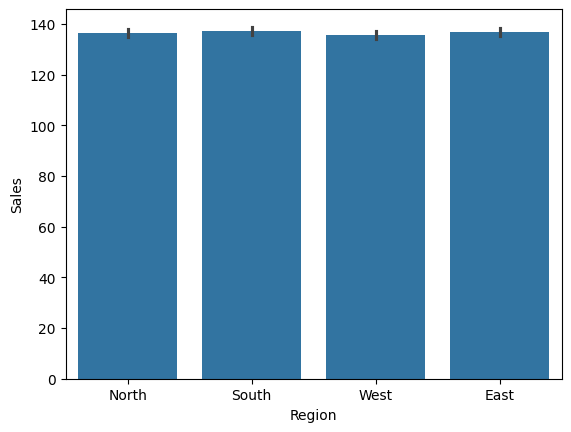

In [11]:
sns.barplot(data = store_df, x = 'Region', y = 'Sales')

* observation : SALES IS EQUAL IN EVERY REGION

<Axes: xlabel='Category', ylabel='Sales'>

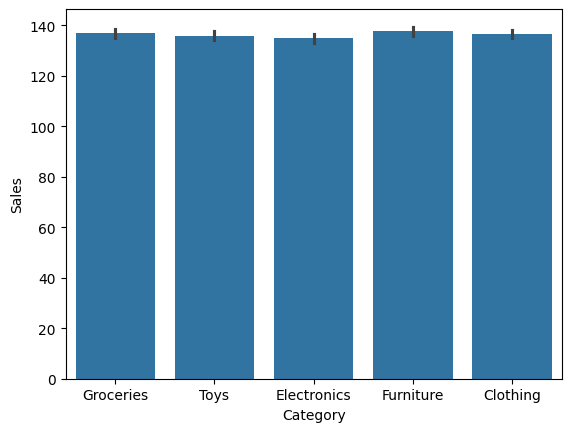

In [12]:
sns.barplot(data = store_df, x = 'Category', y = 'Sales')

* here you can see furniture has a little edge in sales 


Text(0.5, 1.0, 'Avg Units Sold by Category')

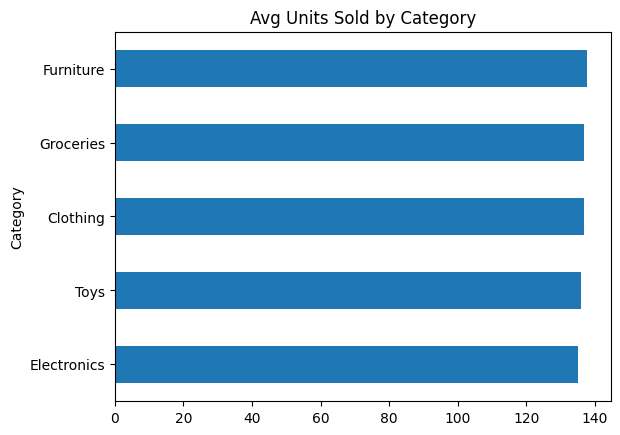

In [13]:
store_df.groupby('Category')['Sales'].mean().sort_values().plot(kind='barh')
plt.title("Avg Units Sold by Category")

Text(0.5, 1.0, 'Sales: Promotion vs No Promotion')

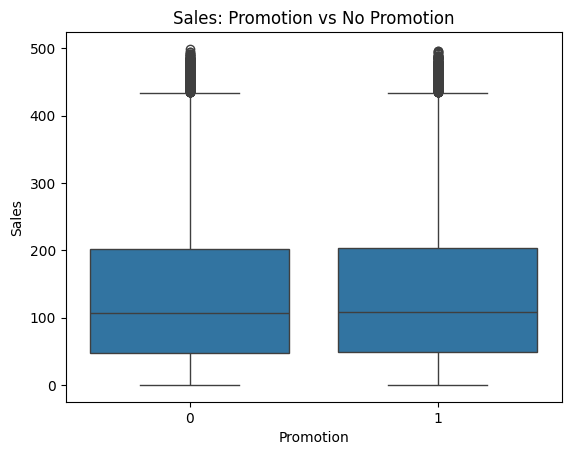

In [14]:
sns.boxplot(x='Promotion', y='Sales', data=store_df)
plt.title("Sales: Promotion vs No Promotion")

Text(0.5, 1.0, 'Price vs Sales')

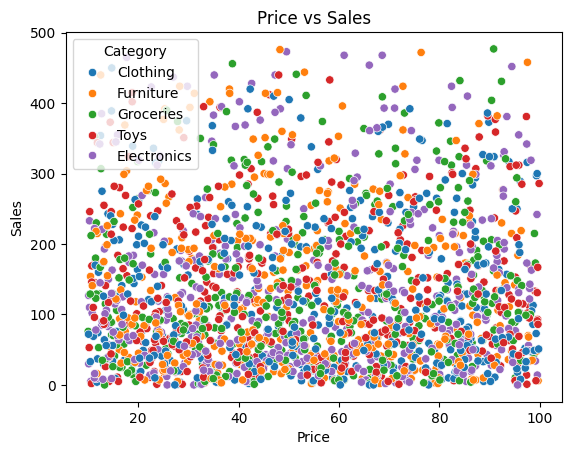

In [15]:
sns.scatterplot(x='Price', y='Sales', hue='Category', data=store_df.sample(2000))
plt.title("Price vs Sales")

Text(0.5, 1.0, 'Correlation Matrix')

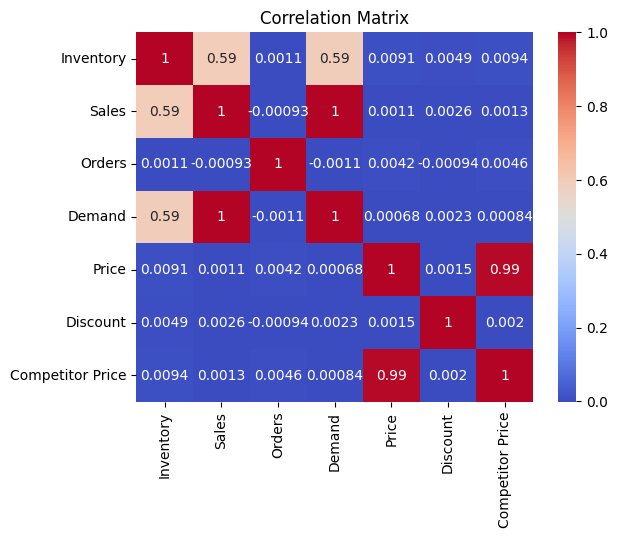

In [17]:
corr = store_df[['Inventory','Sales','Orders',
           'Demand','Price','Discount','Competitor Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

* OBSERVATION : I AM NOT DROPPING THE COLUMN STORE ID BECAUSE I WANT TO SEE HOW EVERY STORE PERFORMED BUT RATHER DROP PRODUCT ID BECAUSE I ALREADY HAVE THE PRODUCT DETAILS

In [53]:
store_df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory',
       'Sales', 'Orders', 'Demand', 'Price', 'Discount', 'Weather',
       'Promotion', 'Competitor Price', 'Seasonality'],
      dtype='object')

In [54]:
store_df.drop('Product ID',inplace = True , axis = 1)

In [55]:
# Hence I would split the date column instead
store_df['Date'] = pd.to_datetime(store_df['Date'])
store_df['Year'] = store_df['Date'].dt.year
store_df['Month'] = store_df['Date'].dt.month
store_df['Day'] = store_df['Date'].dt.day

In [56]:
# dropping the date column
store_df.drop('Date', inplace = True , axis = 1)

In [57]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Store ID          73100 non-null  object 
 1   Category          73100 non-null  object 
 2   Region            73100 non-null  object 
 3   Inventory         73100 non-null  int64  
 4   Sales             73100 non-null  int64  
 5   Orders            73100 non-null  int64  
 6   Demand            73100 non-null  float64
 7   Price             73100 non-null  float64
 8   Discount          73100 non-null  int64  
 9   Weather           73100 non-null  object 
 10  Promotion         73100 non-null  int64  
 11  Competitor Price  73100 non-null  float64
 12  Seasonality       73100 non-null  object 
 13  Year              73100 non-null  int32  
 14  Month             73100 non-null  int32  
 15  Day               73100 non-null  int32  
dtypes: float64(3), int32(3), int64(5), objec

* FROM WHAT I CAN SEE FROM HERE MAPPING OF CATEGORICAL COLUMN WOULD NOT BE THE WRITE DECISION BECAUSE EVERY OBJECT COLUMN HAS MORE THAN 2 VALUE. SO DOING ENCODING HERE WOULD BE WRITE OPTION

* BUT FISRT SPLIT THE DATE SET

In [28]:
X = store_df.drop('Sales', axis = 1)
Y = store_df['Sales']

print(X.shape)
print(Y.shape)

(73100, 15)
(73100,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,random_state=42,test_size=0.25)

In [59]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols])


encoded_cols = encoder.get_feature_names_out(categorical_cols).tolist()


X_train[encoded_cols] = encoder.transform(X_train[categorical_cols])
X_test[encoded_cols]  = encoder.transform(X_test[categorical_cols])


X_train.drop(columns=categorical_cols, inplace=True)
X_test.drop(columns=categorical_cols, inplace=True)

In [63]:
from sklearn.model_selection import TimeSeriesSplit , cross_val_score
def training(model) :
    tscv = TimeSeriesSplit(n_splits=5)

    scores  = cross_val_score(
        model, X_train,y_train, cv = tscv, scoring = 'neg_root_mean_squared_error'
    )
    print("RMSE per fold:", -scores)
    print("Mean RMSE:", -scores.mean())
    print("Std:", scores.std())   # lower std = more stable model

In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42, n_jobs = -1, max_depth=5, n_estimators=100)
training(model)

RMSE per fold: [8.72079334 8.73552055 8.80137298 8.77342579 8.81558056]
Mean RMSE: 8.769338644262216
Std: 0.036555515176841434


* model's predictions are off by ~9 units from the actual sales

In [65]:
from sklearn.metrics import mean_absolute_error, r2_score
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("R² :", r2_score(y_test, preds)) 

MAE: 7.488839775498487
R² : 0.9934804766554033


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

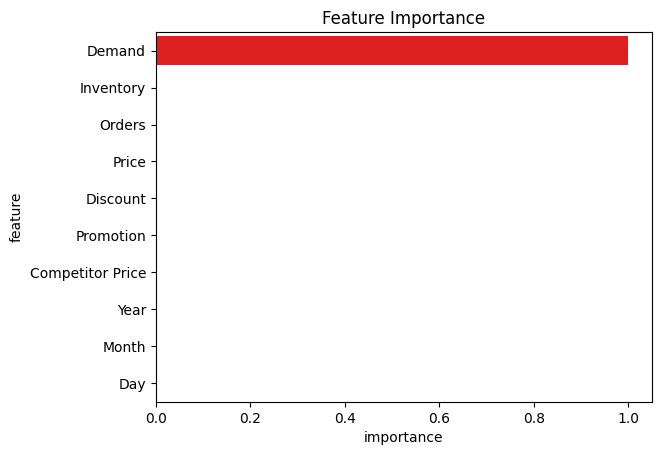

In [66]:
importance_df = pd.DataFrame({
  'feature' : X_train.columns,
  'importance' : model.feature_importances_
}).sort_values('importance', ascending=False)

plt.title("Feature Importance")
sns.barplot(data=importance_df.head(10), x='importance',y='feature',color='red')

# XGBOOST

In [68]:
from xgboost import XGBRegressor

model2 = XGBRegressor(random_state = 42, n_estimators = 100)
training(model2)

RMSE per fold: [9.03140926 8.74951839 8.7883749  8.64635468 8.66740036]
Mean RMSE: 8.776611518859863
Std: 0.13761411829207654


In [69]:
model2.fit(X_train, y_train)
preds = model2.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("R² :", r2_score(y_test, preds)) 

MAE: 7.262893199920654
R² : 0.99382084608078


<Axes: title={'center': 'Feature Importance'}, xlabel='Importance', ylabel='Features'>

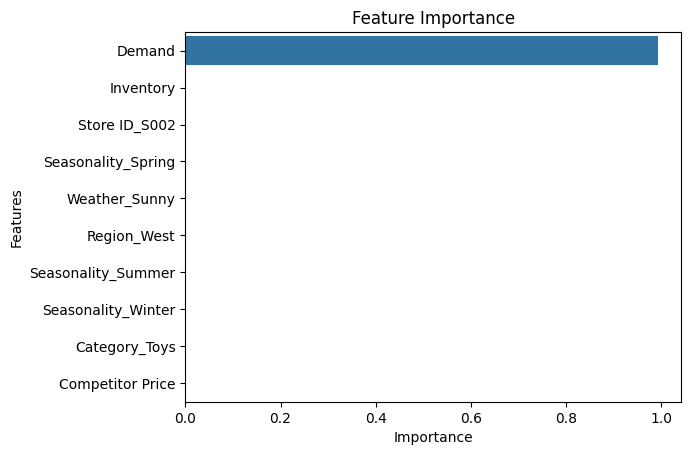

In [70]:
importance_df_2 = pd.DataFrame({
    'Features' : X_train.columns,
    'Importance' : model2.feature_importances_
}).sort_values('Importance', ascending=False)

plt.title("Feature Importance")
sns.barplot(data = importance_df_2.head(10), x = 'Importance', y = 'Features')